# 🧠 Model C: Multimodal Product Classification using LSTM + ViT

---

## Introduction

In this notebook, we build **Model C** — a multimodal deep learning model that classifies e-commerce products into categories by jointly learning from **text** (product title + description) and **images** (product photos).

### Why Multimodal?
A product listing rarely tells the full story through words alone, and an image without context can be ambiguous. By combining both modalities, we let the model leverage the strengths of each:
- **Text** carries semantic meaning: brand names, material descriptions, category keywords.
- **Images** carry visual structure: shape, color, texture — things words sometimes fail to capture.

### Architecture at a Glance
| Component | Role |
|-----------|------|
| **LSTM** | Encodes the combined title + description text into a fixed-size feature vector |
| **Vision Transformer (ViT)** | Encodes the product image into a rich visual feature vector |
| **Fusion Layer** | Concatenates text and image features into a unified representation |
| **Classifier** | Maps fused features to one of 5 product categories |

### Dataset Overview
- **Source:** Nike product catalog
- **Total samples:** 6,079 products
- **Classes:** `shoes`, `tshirts_tops`, `hats_headwear`, `shorts`, `pants_trousers`,`hoodies_sweatshirts`
- **Text feature:** `text` + `image` (concatenated)
- **Image feature:** local image file referenced by `image_name`
- **Target:** `label_raw`

> **Note:** `product_url` and `image_urls` are kept in the dataset for reference only — they are **not** used during training.


In [4]:
!rm -rf /content/drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import os

PROJECT_PATH = "/content/drive/MyDrive/StyleSense-Multimodal"

CSV_PATH = PROJECT_PATH + "/data/Multimodal_Dataset.csv"

# الصور بعد ما نسخناها من Drive لـ Colab RAM
IMAGES_PATH = "/content/images"

# النتائج تفضل تتحفظ في Drive
RESULTS_PATH = PROJECT_PATH + "/results"

os.makedirs(RESULTS_PATH, exist_ok=True)

print("CSV:", CSV_PATH)
print("Images:", IMAGES_PATH)
print("Results:", RESULTS_PATH)

print("Classes folders:")
print(os.listdir(IMAGES_PATH))

CSV: /content/drive/MyDrive/StyleSense-Multimodal/data/Multimodal_Dataset.csv
Images: /content/images
Results: /content/drive/MyDrive/StyleSense-Multimodal/results
Classes folders:
['tshirts_tops', 'hoodies_sweatshirts', 'shoes', 'shorts', 'hats_headwear', 'pants_trousers']


In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

---
## 3. Load Dataset

Let's load the CSV and take a first look at the data — distribution of labels, missing values, and the raw text we'll be working with.

In [23]:
file_path = "/content/drive/MyDrive/StyleSense-Multimodal/data/multimodal_dataset.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
print(df["label_raw"].value_counts())

                                               image  \
0  https://static.nike.com/a/images/t_default/u_9...   
1  https://static.nike.com/a/images/t_default/u_9...   
2  https://static.nike.com/a/images/t_default/u_1...   
3  https://static.nike.com/a/images/t_default/u_9...   
4  https://static.nike.com/a/images/t_default/u_9...   

                                                text            label_raw  \
0  seattle mariners authentic collection standard...  hoodies_sweatshirts   
1  cleveland guardians authentic collection men's...  hoodies_sweatshirts   
2  jalen hurts men's fleece hoodie.. jalen hurts ...  hoodies_sweatshirts   
3  miami dolphins pass accuracy men's dri-fit nfl...  hoodies_sweatshirts   
4  brooklyn nets club men's nba pullover hoodie.....  hoodies_sweatshirts   

       label  text_length  word_count  \
0  outerwear          203          26   
1  outerwear          155          20   
2  outerwear           71          12   
3  outerwear          147          2

In [24]:
print(os.listdir("/content/drive/MyDrive/StyleSense-Multimodal/data"))

['multimodal_dataset.csv']


In [25]:
#Clean Data + Image Paths
df = df.dropna(subset=["text", "label_raw", "image_name"]).copy()

df["image_path"] = df["image_name"].apply(lambda x: os.path.join(IMAGES_PATH, x))

df = df[df["image_path"].apply(os.path.exists)].copy()

print("Final rows:", len(df))
print(df[["text", "label_raw", "image_path"]].head())
print(df["label_raw"].value_counts())

Final rows: 6079
                                                text            label_raw  \
0  seattle mariners authentic collection standard...  hoodies_sweatshirts   
1  cleveland guardians authentic collection men's...  hoodies_sweatshirts   
2  jalen hurts men's fleece hoodie.. jalen hurts ...  hoodies_sweatshirts   
3  miami dolphins pass accuracy men's dri-fit nfl...  hoodies_sweatshirts   
4  brooklyn nets club men's nba pullover hoodie.....  hoodies_sweatshirts   

                                          image_path  
0  /content/images/hoodies_sweatshirts/5b4490af2c...  
1  /content/images/hoodies_sweatshirts/f46b1944b9...  
2  /content/images/hoodies_sweatshirts/7f16af3c87...  
3  /content/images/hoodies_sweatshirts/d8fcdf6f67...  
4  /content/images/hoodies_sweatshirts/0a67a50bce...  
label_raw
shoes                  1366
hoodies_sweatshirts    1355
tshirts_tops           1185
hats_headwear          1139
shorts                  517
pants_trousers          517
Name: count,

---
##  Label Encoding & Dataset Splits

We encode string labels as integers, then split the data into **70% train / 15% validation / 15% test** sets using stratified sampling to preserve class proportions across all splits.

In [26]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label_raw"])

num_classes = len(label_encoder.classes_)

class_names = list(label_encoder.classes_)

print("Classes:", class_names)
print("Number of classes:", num_classes)

with open(os.path.join(RESULTS_PATH, "model_C_label_classes.json"), "w") as f:
    json.dump(class_names, f, indent=4)

Classes: ['hats_headwear', 'hoodies_sweatshirts', 'pants_trousers', 'shoes', 'shorts', 'tshirts_tops']
Number of classes: 6


In [27]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label_encoded"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_encoded"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4255
Validation: 912
Test: 912


In [28]:
#Text Preprocessing for LSTM

MAX_WORDS = 10000
MAX_LEN = 60

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"].astype(str))

X_txt_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_txt_val = pad_sequences(
    tokenizer.texts_to_sequences(val_df["text"].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_txt_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["text"].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

with open(os.path.join(RESULTS_PATH, "model_C_tokenizer.json"), "w") as f:
    f.write(tokenizer.to_json())

print(X_txt_train.shape)
print(X_txt_val.shape)
print(X_txt_test.shape)

(4255, 60)
(912, 60)
(912, 60)


In [29]:
#Image Loading Function
IMG_SIZE = 224

def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image

In [30]:
#Build TensorFlow Datasets
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

y_train = train_df["label_encoded"].values
y_val = val_df["label_encoded"].values
y_test = test_df["label_encoded"].values

train_paths = train_df["image_path"].values
val_paths = val_df["image_path"].values
test_paths = test_df["image_path"].values

def create_dataset(image_paths, text_sequences, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, text_sequences, labels))

    def process(path, text, label):
        image = load_image(path)
        return {"image_input": image, "text_input": text}, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, X_txt_train, y_train, shuffle=True)
val_ds = create_dataset(val_paths, X_txt_val, y_val)
test_ds = create_dataset(test_paths, X_txt_test, y_test)

print("Datasets are ready")

Datasets are ready


In [31]:
#Vision Transformer Blocks
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

In [32]:
#Model Architecture: LSTM + ViT + Fusion

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_UNITS = [128, 64]
TRANSFORMER_LAYERS = 4
MLP_HEAD_UNITS = [256, 128]

# Image Input
image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

patches = PatchExtractor(PATCH_SIZE)(image_input)
encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

for _ in range(TRANSFORMER_LAYERS):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=PROJECTION_DIM,
        dropout=0.1
    )(x1, x1)

    x2 = layers.Add()([attention_output, encoded_patches])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

    x3 = layers.Dense(TRANSFORMER_UNITS[0], activation="gelu")(x3)
    x3 = layers.Dropout(0.1)(x3)
    x3 = layers.Dense(PROJECTION_DIM, activation="gelu")(x3)

    encoded_patches = layers.Add()([x3, x2])

image_features = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
image_features = layers.GlobalAveragePooling1D()(image_features)
image_features = layers.Dense(256, activation="relu")(image_features)
image_features = layers.Dropout(0.3)(image_features)

# Text Input
text_input = layers.Input(shape=(MAX_LEN,), name="text_input")

text_features = layers.Embedding(
    input_dim=MAX_WORDS,
    output_dim=128,
    input_length=MAX_LEN
)(text_input)

text_features = layers.LSTM(128, return_sequences=False)(text_features)
text_features = layers.Dense(128, activation="relu")(text_features)
text_features = layers.Dropout(0.3)(text_features)

# Fusion
combined = layers.concatenate([image_features, text_features])

z = layers.Dense(256, activation="relu")(combined)
z = layers.Dropout(0.4)(z)

z = layers.Dense(128, activation="relu")(z)
z = layers.Dropout(0.3)(z)

output = layers.Dense(num_classes, activation="softmax")(z)

model = models.Model(
    inputs=[image_input, text_input],
    outputs=output,
    name="Model_C_LSTM_ViT_Fusion"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model_C_LSTM_ViT_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor_1   │ (None, None, 768) │          0 │ image_input[0][0] │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 196, 64)   │     61,760 │ patch_extractor_… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 196, 128)  │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 196, 64)   │      8,256 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 196, 64)   │          0 │ dense_16[0][0],   │
│                     │                   │            │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 196, 128)  │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 196, 64)   │      8,256 │ dropout_15[0][0]

 Total params: 1,971,654 (7.52 MB)

 Trainable params: 1,971,654 (7.52 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

This step defines how the model will be trained.

## Settings

- Optimizer: Adam  
- Loss Function: Sparse Categorical Crossentropy  
- Metric: Accuracy  

## Summary

- Adam is used to update model weights  
- The loss function measures prediction error  
- Accuracy is used to evaluate performance  

In [33]:
#Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
#Callbacks
model_path = os.path.join(RESULTS_PATH, "model_C_lstm_vit.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        model_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Model Training

This step trains the model using both image and text data.

## Training Setup

- Inputs: image data + text data  
- Labels: target classes  
- Validation: separate validation set is used during training  

## Parameters

- Epochs: 15
- Batch Size: 16  
- Callback: Early stopping  

## Summary

- The model learns from training data  
- Validation data is used to monitor performance  
- Early stopping helps prevent overfitting  
- Training history is saved for later analysis  

In [35]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2434 - loss: 1.7612
Epoch 1: val_accuracy improved from None to 0.39912, saving model to /content/drive/MyDrive/StyleSense-Multimodal/results/model_C_lstm_vit.keras

Epoch 1: finished saving model to /content/drive/MyDrive/StyleSense-Multimodal/results/model_C_lstm_vit.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.2996 - loss: 1.6957 - val_accuracy: 0.3991 - val_loss: 1.5425 - learning_rate: 1.0000e-04
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3619 - loss: 1.6197
Epoch 2: val_accuracy improved from 0.39912 to 0.40680, saving model to /content/drive/MyDrive/StyleSense-Multimodal/results/model_C_lstm_vit.keras

Epoch 2: finished saving model to /content/drive/MyDrive/StyleSense-Multimodal/results/model_C_lstm_vit.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.3838 - loss: 1.5787 - val_accuracy: 0.4068 - val_loss: 1.5079 - learning_rate: 1.0000e-04
Epoch 3/15
133/13

In [18]:
!cp -r "/content/drive/MyDrive/StyleSense-Multimodal/assets/images" /content/

import os

print(os.listdir("/content/images"))

# Model Evaluation

This step evaluates the model on the test dataset.

## Evaluation Setup

- Inputs: image data + text data  
- Labels: test labels  

## Output

- Test Loss: measures prediction error  
- Test Accuracy: shows how many predictions are correct  

## Summary

- The model is tested on unseen data  
- Results indicate final performance  
- Used to check how well the model generalizes  

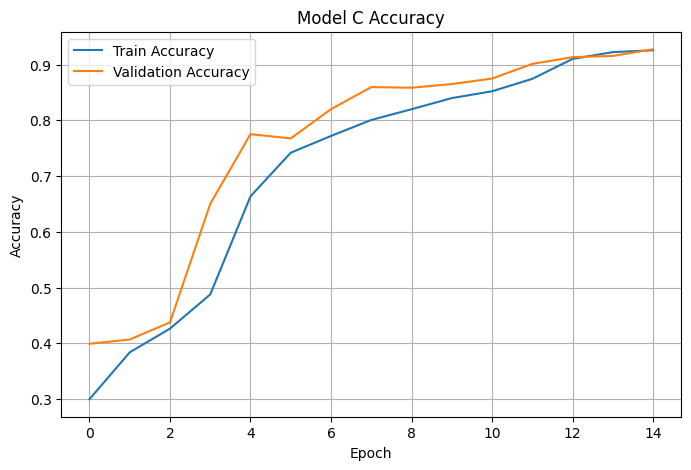

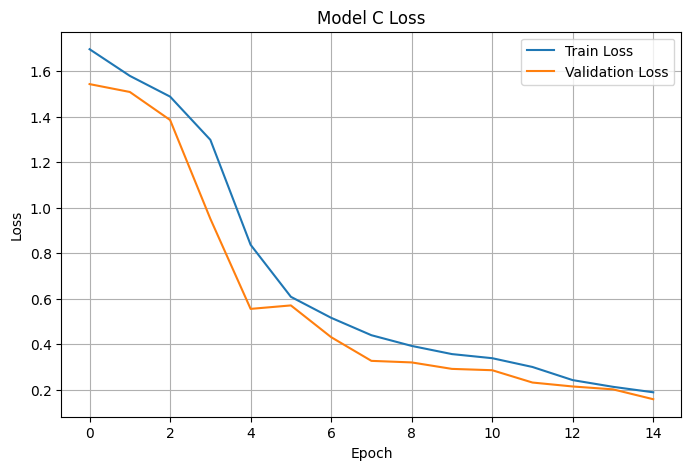

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model C Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(RESULTS_PATH, "model_C_accuracy.png"))
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model C Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(RESULTS_PATH, "model_C_loss.png"))
plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9287 - loss: 0.1844
Test Loss: 0.1843910813331604
Test Accuracy: 0.9287280440330505


In [38]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

results = {
    "model_name": "Model C - LSTM + ViT Fusion",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "classification_report": report
}

with open(os.path.join(RESULTS_PATH, "model_C_evaluation_results.json"), "w") as f:
    json.dump(results, f, indent=4)

print("Evaluation results saved.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step
                     precision    recall  f1-score   support

      hats_headwear       0.98      1.00      0.99       171
hoodies_sweatshirts       0.83      0.89      0.86       204
     pants_trousers       1.00      0.97      0.99        77
              shoes       1.00      1.00      1.00       205
             shorts       0.96      0.97      0.97        78
       tshirts_tops       0.87      0.78      0.82       177

           accuracy                           0.93       912
          macro avg       0.94      0.94      0.94       912
       weighted avg       0.93      0.93      0.93       912

Evaluation results saved.


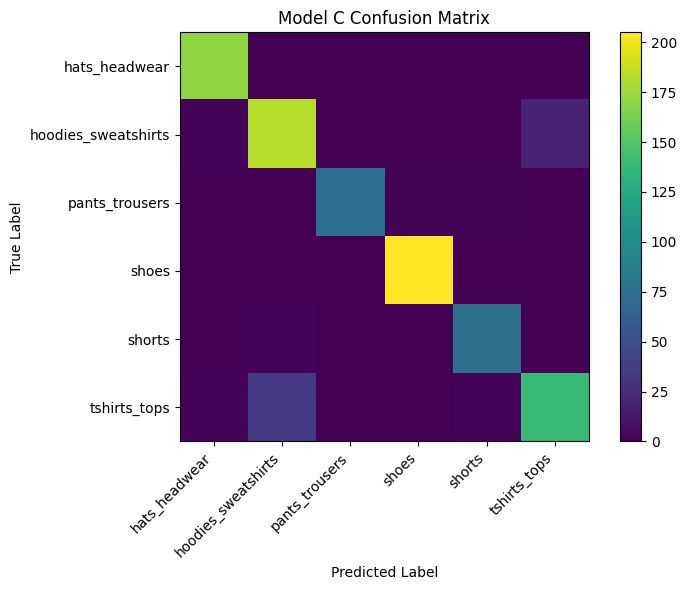

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Model C Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "model_C_confusion_matrix.png"))
plt.show()

Model Loading & Preparation

In [40]:
final_model_path = os.path.join(RESULTS_PATH, "model_C_final.keras")
model.save(final_model_path)

print("Final model saved at:", final_model_path)

Final model saved at: /content/drive/MyDrive/StyleSense-Multimodal/results/model_C_final.keras


In [41]:
model_c_code = r'''
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
MAX_LEN = 60
MAX_WORDS = 10000

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4


class PatchExtractor(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)


def build_model(num_classes):
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    patches = PatchExtractor(PATCH_SIZE)(image_input)
    encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    for _ in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM,
            dropout=0.1
        )(x1, x1)

        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        x3 = layers.Dense(128, activation="gelu")(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(PROJECTION_DIM, activation="gelu")(x3)

        encoded_patches = layers.Add()([x3, x2])

    image_features = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    image_features = layers.GlobalAveragePooling1D()(image_features)
    image_features = layers.Dense(256, activation="relu")(image_features)
    image_features = layers.Dropout(0.3)(image_features)

    text_input = layers.Input(shape=(MAX_LEN,), name="text_input")

    text_features = layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    )(text_input)

    text_features = layers.LSTM(128, return_sequences=False)(text_features)
    text_features = layers.Dense(128, activation="relu")(text_features)
    text_features = layers.Dropout(0.3)(text_features)

    combined = layers.concatenate([image_features, text_features])

    z = layers.Dense(256, activation="relu")(combined)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(128, activation="relu")(z)
    z = layers.Dropout(0.3)(z)

    output = layers.Dense(num_classes, activation="softmax")(z)

    model = models.Model(
        inputs=[image_input, text_input],
        outputs=output,
        name="Model_C_LSTM_ViT_Fusion"
    )

    return model
'''

with open(os.path.join(RESULTS_PATH, "model_C.py"), "w") as f:
    f.write(model_c_code)

print("model_C.py saved.")

model_C.py saved.


In [42]:
print("Saved files:")
for file in os.listdir(RESULTS_PATH):
    print(file)

Saved files:
model_C_label_classes.json
model_C_tokenizer.json
model_C_lstm_vit.keras
model_C_accuracy.png
model_C_loss.png
model_C_evaluation_results.json
model_C_confusion_matrix.png
model_C_final.keras
model_C.py


In [44]:
from tensorflow.keras import layers
import tensorflow as tf

class PatchExtractor(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

In [45]:
import json
import numpy as np
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model(
    RESULTS_PATH + "/model_C_final.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "PatchEncoder": PatchEncoder
    },
    compile=False
)

with open(RESULTS_PATH + "/model_C_label_classes.json", "r") as f:
    label_classes = json.load(f)

with open(RESULTS_PATH + "/model_C_tokenizer.json", "r") as f:
    tokenizer = tokenizer_from_json(f.read())

print("Everything loaded ✅")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Everything loaded ✅


Text & image Preprocessing

In [46]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0
    return np.expand_dims(img, axis=0)


def preprocess_text(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=60, padding="post", truncating="post")
    return padded

Prediction

In [47]:
def predict_style(img_path, text):
    img = preprocess_image(img_path)
    txt = preprocess_text(text)

    pred = model.predict({
        "image_input": img,
        "text_input": txt
    })

    class_id = np.argmax(pred)
    label = label_classes[class_id]
    confidence = pred[0][class_id]

    print("Prediction:", label)
    print("Confidence:", round(float(confidence) * 100, 2), "%")
    print("\nAll probabilities:")
    for cls, prob in zip(label_classes, pred[0]):
        print(f"{cls}: {round(float(prob) * 100, 2)}%")

Testing





In [59]:
predict_style(
     img_path="/content/0ac8bc396657c2e97981babe62b5c091.jpg",
     text="black hat headwear cap stylish accessory"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Prediction: hats_headwear
Confidence: 99.85 %

All probabilities:
hats_headwear: 99.85%
hoodies_sweatshirts: 0.0%
pants_trousers: 0.0%
shoes: 0.15%
shorts: 0.0%
tshirts_tops: 0.0%


In [53]:
predict_style(
    img_path="/content/images/hoodies_sweatshirts/d8fcdf6f67d5be03f4b98145f2eb0374.jpg",
     text="miami dolphins pass accuracy men's dri-fit nfl long-sleeve hooded top.. miami dolphins pass accuracy men's dri-fit nfl long-sleeve hooded top at. ."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Prediction: hoodies_sweatshirts
Confidence: 98.93 %

All probabilities:
hats_headwear: 0.03%
hoodies_sweatshirts: 98.93%
pants_trousers: 0.0%
shoes: 0.0%
shorts: 0.0%
tshirts_tops: 1.04%


In [49]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))

Streaming output truncated to the last 5000 lines.
/content/images/tshirts_tops/dc775feec26ddd165a3b3f880d5e5cc7.jpg
/content/images/tshirts_tops/ab550aaca7ef60722b1b909da8c40c3f.jpg
/content/images/tshirts_tops/bc28e976d3235f32d3a146c14e371dbd.jpg
/content/images/tshirts_tops/546c5ab3d94efc1f14d36cf341007bc6.jpg
/content/images/tshirts_tops/56539be489c9ba592ece7611dd3f3a6f.jpg
/content/images/tshirts_tops/9192a760b091bd66cd2c7047dbfc79af.jpg
/content/images/tshirts_tops/803296bdb876426b54a82709ffc8609a.jpg
/content/images/tshirts_tops/46038ce5e2fe26a7b4bbc4497119ab48.jpg
/content/images/tshirts_tops/a3cf8183c203835b023a26b3f2b4de80.jpg
/content/images/tshirts_tops/9223250183942f608c779982bf3e1006.jpg
/content/images/tshirts_tops/51c4b161532912534f2d0f14af255a67.jpg
/content/images/tshirts_tops/d2cacadd8e5ed425bdfc038e8b525620.jpg
/content/images/tshirts_tops/3379aa990ac7906fb683c2d3486f9d60.jpg
/content/images/tshirts_tops/6ce0341b776870cd1f1438136597a9ca.jpg
/content/images/tshirts_t